In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt



In [4]:
DATA_PATH = "../datasets/lines.csv"
RESULTS_DIR = "../results/Q1"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Q1 results folder is ready:", RESULTS_DIR)

Q1 results folder is ready: ../results/Q1


In [5]:
D = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1)

print("Data shape:", D.shape)
print("First five rows:")
print(D[:5])

Data shape: (100, 6)
First five rows:
[[ -5.30547099  -4.06009155  -5.26129006 -12.66633342  -3.79615021
    3.69171161]
 [ -5.5403588   -5.0031803   -3.99259187 -11.00772693  -3.98562503
    4.90000402]
 [ -4.98212753  -4.58449362  -4.33122591 -11.69731474  -3.58927699
    5.04686274]
 [ -4.49570614  -5.06413838  -4.78201809 -11.97801037  -3.59707103
    4.63593624]
 [ -4.44215386  -4.41137023  -4.5675092  -12.41495176  -2.79950409
    4.73969871]]


## Q1)a

In [6]:
x1 = D[:, 0]   
y1 = D[:, 3]   

print("x1 shape:", x1.shape)
print("y1 shape:", y1.shape)
print("First five x1 values:", x1[:5])
print("First five y1 values:", y1[:5])

x1 shape: (100,)
y1 shape: (100,)
First five x1 values: [-5.30547099 -5.5403588  -4.98212753 -4.49570614 -4.44215386]
First five y1 values: [-12.66633342 -11.00772693 -11.69731474 -11.97801037 -12.41495176]


In [7]:
def fit_line_tls(x, y):
    points = np.column_stack((x, y))
    mean_point = np.mean(points, axis=0)
    centered_points = points - mean_point
    scatter_matrix = centered_points.T @ centered_points
    eigenvalues, eigenvectors = np.linalg.eigh(scatter_matrix)
    normal = eigenvectors[:, np.argmin(eigenvalues)]
    normal = normal / np.linalg.norm(normal)
    a, b = normal
    d = a * mean_point[0] + b * mean_point[1]
    if b < 0:
        a, b, d = -a, -b, -d
    return a, b, d

### Fit TLS line for Q1(a)

In [8]:
a_q1a, b_q1a, d_q1a = fit_line_tls(x1, y1)

print("Q1(a): TLS line parameters for the first line")
print(f"a = {a_q1a:.6f}")
print(f"b = {b_q1a:.6f}")
print(f"d = {d_q1a:.6f}")

slope_q1a = -a_q1a / b_q1a
intercept_q1a = d_q1a / b_q1a

print("\nEquivalent slope-intercept form:")
print(f"y = {slope_q1a:.6f}x + {intercept_q1a:.6f}")

Q1(a): TLS line parameters for the first line
a = -0.773562
b = 0.633721
d = -3.794192

Equivalent slope-intercept form:
y = 1.220666x + -5.987165


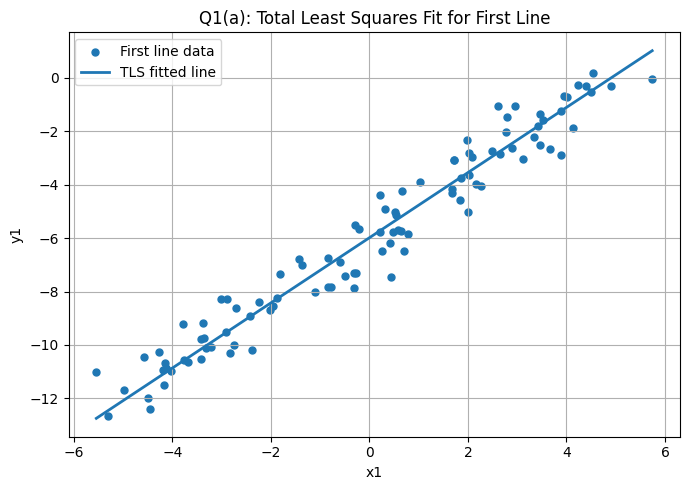

In [9]:
x_min, x_max = x1.min(), x1.max()
x_line = np.linspace(x_min, x_max, 200)
y_line = (d_q1a - a_q1a * x_line) / b_q1a

plt.figure(figsize=(7, 5))
plt.scatter(x1, y1, label="First line data", s=25)
plt.plot(x_line, y_line, label="TLS fitted line", linewidth=2)

plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Q1(a): Total Least Squares Fit for First Line")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(f"{RESULTS_DIR}/q1a_tls_first_line.png", dpi=300)
plt.show()

## Q1(b)

In [10]:
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

points_all = np.column_stack((X_all, Y_all))

print("All points shape:", points_all.shape)
print("First five combined points:")
print(points_all[:5])

All points shape: (300, 2)
First five combined points:
[[ -5.30547099 -12.66633342]
 [ -4.06009155  -3.79615021]
 [ -5.26129006   3.69171161]
 [ -5.5403588  -11.00772693]
 [ -5.0031803   -3.98562503]]


In [11]:
def line_from_two_points(p1, p2):
    direction = p2 - p1
    normal = np.array([direction[1], -direction[0]], dtype=np.float64)
    norm = np.linalg.norm(normal)
    if norm == 0:
        return None
    normal = normal / norm
    a, b = normal
    d = a * p1[0] + b * p1[1]
    return a, b, d

def point_line_distances(points, model):
    a, b, d = model
    distances = np.abs(a * points[:, 0] + b * points[:, 1] - d)
    return distances


def ransac_line(points, num_iterations=3000, distance_threshold=0.7, random_seed=42):
    rng = np.random.default_rng(random_seed)
    best_model = None
    best_inlier_mask = None
    best_inlier_count = 0
    n_points = points.shape[0]
    for _ in range(num_iterations):
        sample_indices = rng.choice(n_points, size=2, replace=False)
        p1 = points[sample_indices[0]]
        p2 = points[sample_indices[1]]
        model = line_from_two_points(p1, p2)
        if model is None:
            continue
        distances = point_line_distances(points, model)
        inlier_mask = distances < distance_threshold
        inlier_count = np.sum(inlier_mask)
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_model = model
            best_inlier_mask = inlier_mask
    return best_model, best_inlier_mask

In [12]:
remaining_points = points_all.copy()
ransac_models = []
ransac_inliers = []
for line_id in range(3):
    model, inlier_mask = ransac_line(
        remaining_points,
        num_iterations=3000,
        distance_threshold=0.7,
        random_seed=42 + line_id
    )
    inlier_points = remaining_points[inlier_mask]
    a, b, d = fit_line_tls(inlier_points[:, 0], inlier_points[:, 1])
    refined_model = (a, b, d)
    ransac_models.append(refined_model)
    ransac_inliers.append(inlier_points)
    slope = -a / b
    intercept = d / b

    print(f"Line {line_id + 1}")
    print(f"Number of inliers: {len(inlier_points)}")
    print(f"a = {a:.6f}")
    print(f"b = {b:.6f}")
    print(f"d = {d:.6f}")
    print(f"y = {slope:.6f}x + {intercept:.6f}")
    print()
    remaining_points = remaining_points[~inlier_mask]

print("Remaining points after detecting three lines:", len(remaining_points))

Line 1
Number of inliers: 106
a = 0.415789
b = 0.909461
d = 1.886151
y = -0.457181x + 2.073921

Line 2
Number of inliers: 79
a = -0.766823
b = 0.641858
d = -3.839533
y = 1.194693x + -5.981904

Line 3
Number of inliers: 78
a = -0.733725
b = 0.679446
d = 0.744364
y = 1.079887x + 1.095545

Remaining points after detecting three lines: 37


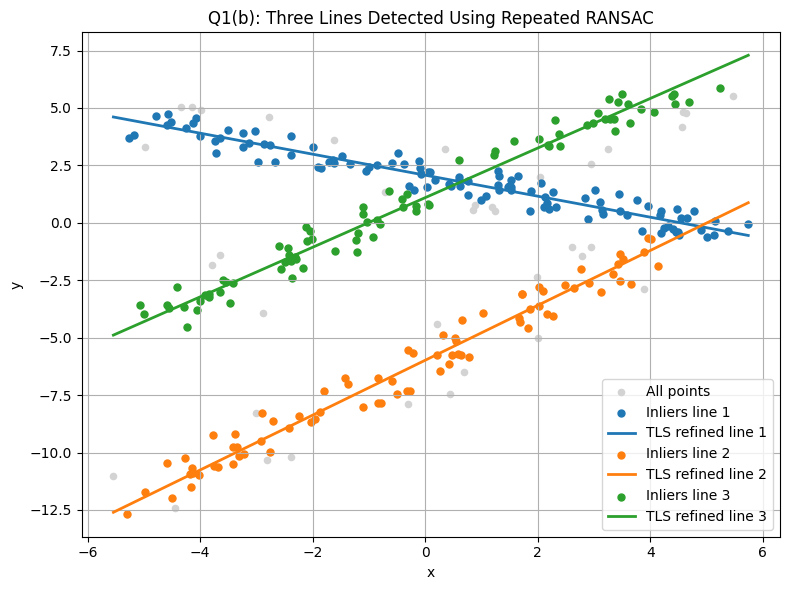

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(points_all[:, 0], points_all[:, 1], color="lightgray", s=20, label="All points")
x_min, x_max = points_all[:, 0].min(), points_all[:, 0].max()
x_line = np.linspace(x_min, x_max, 300)
for i, model in enumerate(ransac_models):
    a, b, d = model
    y_line = (d - a * x_line) / b

    inlier_points = ransac_inliers[i]

    plt.scatter(
        inlier_points[:, 0],
        inlier_points[:, 1],
        s=25,
        label=f"Inliers line {i + 1}"
    )

    plt.plot(
        x_line,
        y_line,
        linewidth=2,
        label=f"TLS refined line {i + 1}"
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Q1(b): Three Lines Detected Using Repeated RANSAC")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(f"{RESULTS_DIR}/q1b_ransac_three_lines.png", dpi=300)
plt.show()

In [ ]:
with open(f"{RESULTS_DIR}/q1_line_parameters.txt", "w") as f:
    f.write("Q1(a): Total Least Squares for first line\n")
    f.write(f"a = {a_q1a:.6f}, b = {b_q1a:.6f}, d = {d_q1a:.6f}\n")
    f.write(f"y = {slope_q1a:.6f}x + {intercept_q1a:.6f}\n\n")

    f.write("Q1(b): Repeated RANSAC with TLS refinement\n")
    for i, model in enumerate(ransac_models):
        a_i, b_i, d_i = model
        slope_i = -a_i / b_i
        intercept_i = d_i / b_i

        f.write(f"Line {i + 1}\n")
        f.write(f"a = {a_i:.6f}, b = {b_i:.6f}, d = {d_i:.6f}\n")
        f.write(f"y = {slope_i:.6f}x + {intercept_i:.6f}\n")
        f.write(f"Inliers = {len(ransac_inliers[i])}\n\n")

print("Saved Q1 line parameters.")